In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import os
import matplotlib as mpl
import math

mpl.rcParams.update({
        "text.usetex": True,
        "font.family": "serif",
        "text.latex.preamble": r"\usepackage{amsmath}"
    })

plt.rcParams.update({'font.size': 20, 'axes.titlesize': 24, 'axes.labelsize': 20, 'legend.fontsize': 14, 'xtick.labelsize': 20, 'ytick.labelsize': 20})

seasons = {
        "DJF": [12, 1, 2],
        "MAM": [3, 4, 5],
        "JJA": [6, 7, 8],
        "SON": [9, 10, 11]
    }

regions_plot = {
    "Africa": {"color": "#c2896c", "lon": [15, 35], "lat": [-20, 5]},
    "Tropical Indian": {"color": "#8fa9b5", "lon": [55, 95], "lat": [-20, 0]},
    "Maritime Continent": {"color": "#bd5172", "lon": [95, 150], "lat": [-10, 10]},
    "North Pacific": {"color": "#797bd0", "lon": [140, 200], "lat": [15, 30]},
    "Tropical Pacific": {"color": "#77587e", "lon": [160, 200], "lat": [-20, 0]},
    "South America": {"color": "#c86c62", "lon": [285, 320], "lat": [-15, 0]},
}


In [8]:
def shift_phase_to_lst(phase_da, lon_da):
    """Shift phase from UTC to local solar time using longitude array.
    Args:
        phase_da (xr.DataArray): phase in UTC, dims (..., lat, lon)
        lon_da (xr.DataArray): longitude array, dims (lon,) or (..., lon)
    Returns:
        xr.DataArray: phase in local solar time (LST)
    """
    # Broadcast lon to match phase_da dimensions
    
    lon2d = xr.broadcast(phase_da, lon_da)[1]
    phase_lst = (phase_da + lon2d / 360 * 24) % 24
    return phase_lst

In [2]:
fit_imerg = xr.open_dataset("/scratch/leko/IMERG/IMERG_1_deg_diurnal/IMERG_diurnal_fit_utc.nc")
fit_ccic=xr.open_dataset('/data/s5/users/lara/master_thesis/data/ccic/CCIC_diurnal_fit_utc.nc')

In [9]:
peak_ccic = fit_ccic.diurnal_phase
peak_ccic = peak_ccic.sel(lon = slice(regions_plot['Africa']['lon'][0], regions_plot['Africa']['lon'][1]), lat = slice(regions_plot['Africa']['lat'][0], regions_plot['Africa']['lat'][1]))
peak_ccic = peak_ccic.assign_coords(lon=(((peak_ccic.lon + 360) % 360))).sortby('lon')
peak_lst = shift_phase_to_lst(peak_ccic, peak_ccic['lon'])
theta = 2 * np.pi * peak_lst / 24 

In [10]:
# Probability densiti function as distance from the mean
def circular_pdf(theta, dim=None, nbins=24):

    # circular mean
    weights = np.cos(np.deg2rad(peak_ccic['lat']))
    sin_mean = np.sin(theta).weighted(weights).mean(dim=['month','lat','lon'])
    cos_mean= np.cos(theta).weighted(weights).mean(dim=['month','lat','lon'])
    theta_mean = np.arctan2(sin_mean, cos_mean)

    # rotate so mean = 0
    theta_rot = (theta - theta_mean + np.pi) % (2 * np.pi) - np.pi

    # convert back to hours
    theta_rot = (theta_rot * 24) / (2 * np.pi)

    # linear percentiles
    pct09 = theta_rot.quantile(0.9, dim=dim)
    pct01 = theta_rot.quantile(0.1, dim=dim)

    theta_mean = ((theta_mean * 24) / (2 * np.pi)) % 24

    #rotate back to that mean is at theta_mean and theta_rot goes from 0 to 24
    theta_rot = (theta_rot + theta_mean) % 24
    pct01 = (pct01 + theta_mean) % 24
    pct09 = (pct09 + theta_mean) % 24

    # histogram
    hist, bin_edges = np.histogram(theta_rot, bins=nbins, density=True)

    return hist, bin_edges,pct01, pct09, theta_mean

In [11]:
hist, bin_edges,pct01, pct09, theta_mean= circular_pdf(theta, dim=['month','lat','lon'], nbins=24)
print(pct01.values, pct09.values, theta_mean.values)


15.300000000000006 1.6333333333333329 17.738013134642422


Text(0, 0.5, 'Probability Density')

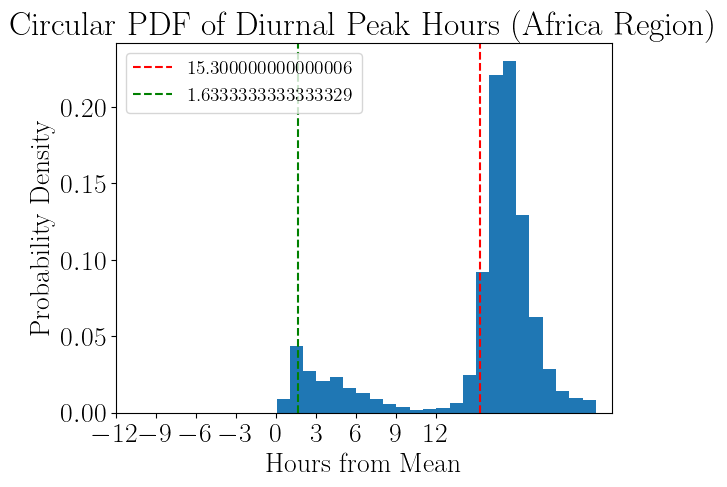

In [12]:
plt.bar(bin_edges[:-1], hist, width=bin_edges[1]-bin_edges[0], align='edge')
plt.axvline(pct01, color='red', linestyle='--', label = str(pct01.values))
plt.axvline(pct09, color='green', linestyle='--', label = str(pct09.values))
plt.xticks(np.arange(-12,13,3))
plt.title('Circular PDF of Diurnal Peak Hours (Africa Region)')
plt.legend()
plt.xlabel('Hours from Mean')
plt.ylabel('Probability Density')

Text(0, 0.5, 'Probability Density')

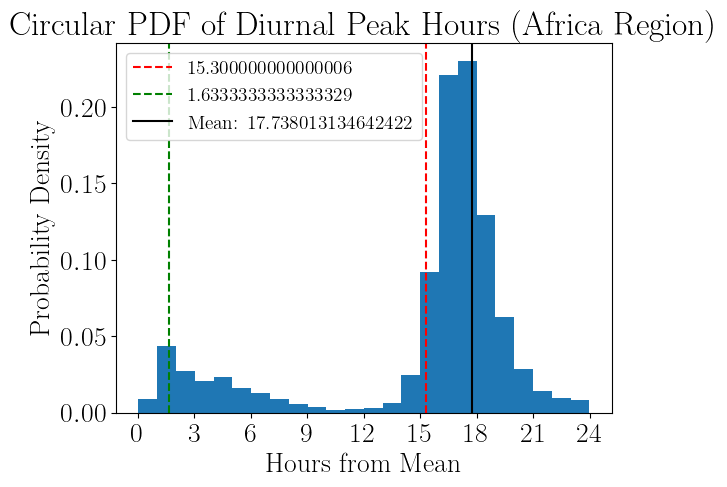

In [13]:
# Move bins so that mean is at theta_mean
plt.bar(bin_edges[:-1], hist, width=bin_edges[1]-bin_edges[0], align='edge')
plt.axvline(pct01, color='red', linestyle='--',label = str(pct01.values))
plt.axvline(pct09, color='green', linestyle='--', label = str(pct09.values))
plt.axvline(theta_mean, color='black', linestyle='-', label = 'Mean: ' + str(theta_mean.values))
plt.xticks(np.arange(0,25,3))
plt.title('Circular PDF of Diurnal Peak Hours (Africa Region)')
plt.legend()
plt.xlabel('Hours from Mean')
plt.ylabel('Probability Density')